# ЛР №1. Запуск открытой модели text-to-image

**Студент:** Власюк Данил Витальевич  
**Группа:** Т26ИИКТ-МИК11  
**Вариант:** 2 — обложка подкаста о городской среде  
**Модель:** `stabilityai/sd-turbo`  
**Ревизия:** `b261bac6fd2cf515557d5d0707481eafa0485ec2`

Ноутбук рассчитан на Google Colab с GPU. После `Runtime → Run all` скачайте файл через **File → Download .ipynb**, чтобы в git остались выводы ячеек. Картинки и JSON дополнительно пакуются в zip в последней ячейке.

Генерацию запускайте только после того, как prompt варианта 2 записан в `configs/run_config.json` (это делается отдельным коммитом в конце работы).


## 1. Среда Colab и зависимости


In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("IN_COLAB =", IN_COLAB)
print("python =", sys.version)

if IN_COLAB:
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    # Clone the course repo so configs/ and src/ match GitHub.
    if not Path("/content/AI_in_creative_media").exists():
        !git clone https://github.com/mart1ny/AI_in_creative_media.git /content/AI_in_creative_media
    %cd /content/AI_in_creative_media/LR1
else:
    # Local run from LR1/notebooks
    %cd ..

print("cwd =", Path.cwd())


IN_COLAB = True
python = 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Cloning into '/content/AI_in_creative_media'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 45 (delta 9), reused 43 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 22.13 KiB | 5.53 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/AI_in_creative_media/LR1
cwd = /content/AI_in_creative_media/LR1


In [2]:
# Colab already has a CUDA PyTorch build. Install only the Diffusers stack.
# transformers 5.17.0 is required: diffusers 0.40.0 needs huggingface-hub>=1.23,
# while transformers 4.x requires huggingface-hub<1.
%pip -q install "diffusers==0.40.0" "transformers==5.17.0" "accelerate>=1.2,<2" "safetensors>=0.5,<1" "Pillow>=11,<13"

import torch
import diffusers

print("torch =", torch.__version__)
print("diffusers =", diffusers.__version__)
print("cuda_available =", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda_device =", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 114.2 MB/s eta 0:00:00
torch = 2.11.0+cu128
diffusers = 0.40.0
cuda_available = True
cuda_device = Tesla T4


## 2. Конфиг, prompt и freeze окружения


In [3]:
from pathlib import Path
import json
import os

ROOT = Path.cwd()
config_path = ROOT / "configs" / "run_config.json"
config = json.loads(config_path.read_text(encoding="utf-8"))
print(json.dumps(config, ensure_ascii=False, indent=2))

prompt = config["prompt"]
if not prompt or str(prompt).startswith("PLACEHOLDER"):
    raise SystemExit(
        "Prompt ещё не зафиксирован. Запишите текст варианта 2 в configs/run_config.json, "
        "сделайте коммит и перезапустите ноутбук."
    )
print("prompt ready, length =", len(prompt))


{
  "student": "Власюк Данил Витальевич",
  "group": "Т26ИИКТ-МИК11",
  "variant": 2,
  "model_id": "stabilityai/sd-turbo",
  "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
  "prompt": "square podcast cover about the urban environment, visual metaphor of a city as a living circulatory system of streets, night aerial view of glowing paths and quiet courtyards, dusk teal and warm brick amber palette, clean centered composition, no text, no logo, no people, no recognizable faces",
  "prompt_structure": {
    "subject": "square podcast cover about the urban environment",
    "metaphor": "city as a living circulatory system of streets; night aerial view of glowing paths and quiet courtyards",
    "palette": "dusk teal and warm brick amber",
    "composition": "clean centered composition",
    "constraints": "no text, no logo, no people, no recognizable faces"
  },
  "seed": 20260920,
  "num_inference_steps": 1,
  "guidance_scale": 0.0,
  "height": 512,
  "width": 512,
  "runs": 2
}

In [4]:
# environment.txt after install, as required by the lab
!python -m pip freeze > reports/environment.txt
print("wrote reports/environment.txt")
!wc -l reports/environment.txt
!python -c "import torch, diffusers; print(torch.__version__); print(diffusers.__version__); print(torch.cuda.is_available())"


wrote reports/environment.txt
704 reports/environment.txt
2.11.0+cu128
0.40.0
True


## 3. Загрузка закреплённой ревизии и два запуска


In [5]:
from datetime import datetime, timezone
import hashlib
import importlib.metadata as md
import os
import platform
import time

import torch
from diffusers import AutoPipelineForText2Image
from IPython.display import display
from PIL import Image

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
if device == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

load_args = {
    "revision": config["revision"],
    "use_safetensors": True,
    "torch_dtype": dtype,
}
if device == "cuda":
    load_args["variant"] = "fp16"

print("loading", config["model_id"], config["revision"], "on", device, dtype)
started = time.perf_counter()
pipeline = AutoPipelineForText2Image.from_pretrained(config["model_id"], **load_args).to(device)
print("model_load_seconds =", round(time.perf_counter() - started, 3))


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def package_versions():
    names = [
        "torch", "torchvision", "diffusers", "transformers",
        "accelerate", "safetensors", "huggingface-hub", "Pillow",
    ]
    out = {}
    for name in names:
        try:
            out[name] = md.version(name)
        except md.PackageNotFoundError:
            out[name] = "not-installed"
    return out


common = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "student": config.get("student"),
    "group": config.get("group"),
    "variant": config.get("variant"),
    "model_id": config["model_id"],
    "revision_requested": config["revision"],
    "prompt": prompt,
    "seed": config["seed"],
    "num_inference_steps": config["num_inference_steps"],
    "guidance_scale": config["guidance_scale"],
    "height": config["height"],
    "width": config["width"],
    "device": device,
    "dtype": str(dtype),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "packages": package_versions(),
    "deterministic_algorithms": True,
    "torch_num_threads": torch.get_num_threads(),
}


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


loading stabilityai/sd-turbo b261bac6fd2cf515557d5d0707481eafa0485ec2 on cuda torch.float16


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


model_load_seconds = 31.663


  0%|          | 0/1 [00:00<?, ?it/s]

run_001 seconds = 1.873 sha256 = 4b14be2c2c8c2e8526e5e5384bd603f0a80fdc71184dd426294bd4b4c29f02fa


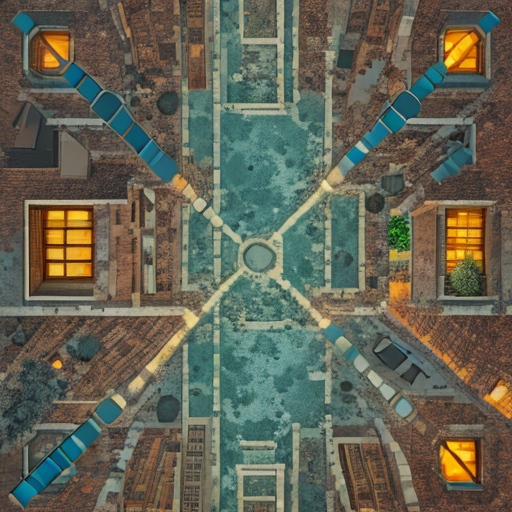

  0%|          | 0/1 [00:00<?, ?it/s]

run_002 seconds = 0.413 sha256 = 4b14be2c2c8c2e8526e5e5384bd603f0a80fdc71184dd426294bd4b4c29f02fa


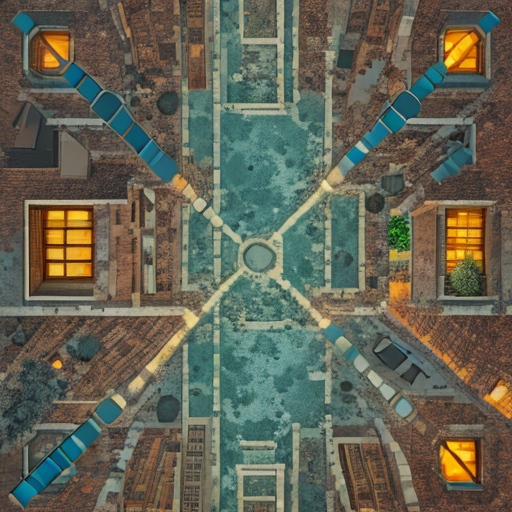

{
  "checked_utc": "2026-09-20T08:30:03.919026+00:00",
  "run_001_sha256": "4b14be2c2c8c2e8526e5e5384bd603f0a80fdc71184dd426294bd4b4c29f02fa",
  "run_002_sha256": "4b14be2c2c8c2e8526e5e5384bd603f0a80fdc71184dd426294bd4b4c29f02fa",
  "exact_sha256_match": true,
  "same_image_size": true,
  "same_image_mode": true,
  "interpretation": "PASS: два запуска в одной зафиксированной среде побитово совпали."
}


In [6]:
manifests = []
for run_number in range(1, int(config["runs"]) + 1):
    run_name = f"run_{run_number:03d}"
    run_dir = ROOT / "artifacts" / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    generator = torch.Generator(device="cpu").manual_seed(int(config["seed"]))
    started = time.perf_counter()
    image = pipeline(
        prompt=prompt,
        num_inference_steps=int(config["num_inference_steps"]),
        guidance_scale=float(config["guidance_scale"]),
        height=int(config["height"]),
        width=int(config["width"]),
        generator=generator,
    ).images[0]
    elapsed = time.perf_counter() - started

    image_path = run_dir / "result.png"
    image.save(image_path)
    with Image.open(image_path) as check:
        observed_size = list(check.size)
        observed_mode = check.mode

    manifest = {
        **common,
        "run": run_number,
        "run_name": run_name,
        "generation_seconds_measured": elapsed,
        "artifact": str(image_path.relative_to(ROOT)),
        "artifact_size_bytes": image_path.stat().st_size,
        "image_size_observed": observed_size,
        "image_mode_observed": observed_mode,
        "sha256": sha256(image_path),
    }
    (run_dir / "manifest.json").write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    (ROOT / "reports" / f"{run_name}.log").write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    manifests.append(manifest)
    print(run_name, "seconds =", round(elapsed, 3), "sha256 =", manifest["sha256"])
    display(image)

same_hash = manifests[0]["sha256"] == manifests[1]["sha256"]
comparison = {
    "checked_utc": datetime.now(timezone.utc).isoformat(),
    "run_001_sha256": manifests[0]["sha256"],
    "run_002_sha256": manifests[1]["sha256"],
    "exact_sha256_match": same_hash,
    "same_image_size": manifests[0]["image_size_observed"] == manifests[1]["image_size_observed"],
    "same_image_mode": manifests[0]["image_mode_observed"] == manifests[1]["image_mode_observed"],
    "interpretation": (
        "PASS: два запуска в одной зафиксированной среде побитово совпали."
        if same_hash
        else "FAIL: SHA-256 различаются. На GPU это может быть недетерминизм CUDA; фиксируем факт."
    ),
}
(ROOT / "reports" / "sha256_comparison.json").write_text(
    json.dumps(comparison, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(comparison, ensure_ascii=False, indent=2))


## 4. Проверка артефактов

Ожидается размер `(512, 512)` и валидный JSON. Конкретный SHA-256 заранее не задаётся.


In [7]:
from PIL import Image
import json

im = Image.open("artifacts/run_001/result.png")
print("run_001", im.size, im.mode)
im = Image.open("artifacts/run_002/result.png")
print("run_002", im.size, im.mode)

!python -m json.tool artifacts/run_001/manifest.json | head -n 40
print("---")
!python -m json.tool reports/sha256_comparison.json


run_001 (512, 512) RGB
run_002 (512, 512) RGB
{
    "created_utc": "2026-09-20T08:30:01.333695+00:00",
    "student": "\u0412\u043b\u0430\u0441\u044e\u043a \u0414\u0430\u043d\u0438\u043b \u0412\u0438\u0442\u0430\u043b\u044c\u0435\u0432\u0438\u0447",
    "group": "\u042226\u0418\u0418\u041a\u0422-\u041c\u0418\u041a11",
    "variant": 2,
    "model_id": "stabilityai/sd-turbo",
    "revision_requested": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
    "prompt": "square podcast cover about the urban environment, visual metaphor of a city as a living circulatory system of streets, night aerial view of glowing paths and quiet courtyards, dusk teal and warm brick amber palette, clean centered composition, no text, no logo, no people, no recognizable faces",
    "seed": 20260920,
    "num_inference_steps": 1,
    "guidance_scale": 0.0,
    "height": 512,
    "width": 512,
    "device": "cuda",
    "dtype": "torch.float16",
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "python": "3

## 5. Намеренная типовая ошибка

В эталонном коде generator создаётся на CPU. Здесь специально вызывается `device="cuda"` и фиксируется симптом. Затем показывается исправление.


In [8]:
import os
import subprocess
import sys

print("current process cuda_available =", torch.cuda.is_available())
print("inference device =", device)
print("broken line = torch.Generator(device='cuda').manual_seed(SEED)")

# On Colab GPU the broken line may succeed. Reproduce the CPU-machine
# symptom from the methodical notes by hiding CUDA from a child process.
child = r"""
import torch
print("child cuda_available =", torch.cuda.is_available())
try:
    torch.Generator(device="cuda").manual_seed(20260920)
    print("child: CUDA generator created (unexpected on CPU-only)")
except Exception as exc:
    print(f"child symptom = {type(exc).__name__}: {exc}")
"""
env = dict(os.environ)
env["CUDA_VISIBLE_DEVICES"] = ""
result = subprocess.run(
    [sys.executable, "-c", child],
    env=env,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

fixed = torch.Generator(device="cpu").manual_seed(int(config["seed"]))
print("fix = torch.Generator(device='cpu').manual_seed(SEED)")
print("CPU generator ok:", fixed)

error_record = {
    "broken_line": 'torch.Generator(device="cuda").manual_seed(SEED)',
    "how_reproduced": "subprocess with CUDA_VISIBLE_DEVICES empty",
    "child_stdout": result.stdout.strip(),
    "fix": 'torch.Generator(device="cpu").manual_seed(SEED)',
    "why_cpu_generator": (
        "Diffusers принимает CPU Generator при инференсе на GPU. "
        "Так seed задаётся одинаково на ноутбуке без CUDA и на Colab."
    ),
}
(ROOT / "reports" / "cuda_generator_error.json").write_text(
    json.dumps(error_record, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(error_record, ensure_ascii=False, indent=2))


current process cuda_available = True
inference device = cuda
broken line = torch.Generator(device='cuda').manual_seed(SEED)
child cuda_available = False
child symptom = AcceleratorError: CUDA error: no CUDA-capable device is detected
Search for `cudaErrorNoDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Device-side assertions were explicitly omitted for this error check; the error probably arose while initializing the DSA handlers.

fix = torch.Generator(device='cpu').manual_seed(SEED)
CPU generator ok: <torch._C.Generator object at 0x7eafab172930>
{
  "broken_line": "torch.Generator(device=\"cuda\").manual_seed(SEED)",
  "how_reproduced": "subprocess with CUDA_VISIBLE_DEVICES empty",
  "child_stdout": "child cuda_available = False\nchild symptom = Accelerat

## 6. Упаковка артефактов для скачивания


In [9]:
from datetime import date
import zipfile

stamp = date.today().isoformat()
zip_path = (Path("/content") if IN_COLAB else ROOT) / f"LR01_variant2_{stamp}.zip"
include = ["artifacts", "reports", "configs", "src", "data"]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in include:
        base = ROOT / folder
        if not base.exists():
            continue
        for file in base.rglob("*"):
            if file.is_file() and file.name != ".gitkeep":
                zf.write(file, file.relative_to(ROOT))

print("zip =", zip_path, "bytes =", zip_path.stat().st_size)
print("files:", zipfile.ZipFile(zip_path).namelist())

if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))
    print("Also download this notebook: File → Download → Download .ipynb")


zip = /content/LR01_variant2_2026-09-20.zip bytes = 1055226
files: ['artifacts/run_001/result.png', 'artifacts/run_001/manifest.json', 'artifacts/run_002/result.png', 'artifacts/run_002/manifest.json', 'reports/environment.txt', 'reports/run_002.log', 'reports/cuda_generator_error.json', 'reports/LR01_report.md', 'reports/run_001.log', 'reports/sha256_comparison.json', 'configs/run_config.json', 'src/run_reproducibility.py', 'src/generate_once.py', 'src/demo_cuda_generator_error.py', 'data/brief.md']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Also download this notebook: File → Download → Download .ipynb
